In [27]:
import pandas as pd

games = pd.read_csv("games.csv")
games_details = pd.read_csv("games_details.csv")
ranking = pd.read_csv("ranking.csv")

/var/folders/2r/46mxdql52bn78bp6pr2cps340000gn/T/ipykernel_93671/3465009782.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv("games_details.csv")


In [28]:
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [29]:
# Keep only columns we need at first
base = games[
    [
        "GAME_ID",
        "GAME_DATE_EST",
        "HOME_TEAM_ID",
        "VISITOR_TEAM_ID",
        "PTS_home",
        "PTS_away",
    ]
].copy()

# Parse date and sort chronologically
base["GAME_DATE_EST"] = pd.to_datetime(base["GAME_DATE_EST"])
base = base.sort_values(["GAME_DATE_EST", "GAME_ID"]).reset_index(drop=True)

base = base.dropna(subset=["PTS_home", "PTS_away"]).copy()
base = base.drop_duplicates(subset=["GAME_ID"]).copy()

# Create target
base["home_team_win"] = (base["PTS_home"] > base["PTS_away"]).astype(int)

print("Base shape:", base.shape)
base.head()


Base shape: (26523, 7)


,GAME_ID,GAME_DATE_EST,HOME_TEAM_ID,VISITOR_TEAM_ID,PTS_home,PTS_away,home_team_win
0,10300001,2003-10-05,1610612762,1610612742,90.0,85.0,1
1,10300002,2003-10-06,1610612763,1610612749,105.0,94.0,1
2,10300003,2003-10-07,1610612765,1610612739,96.0,100.0,0
3,10300004,2003-10-07,1610612742,1610612753,99.0,89.0,1
4,10300005,2003-10-07,1610612757,1610612745,104.0,80.0,1


In [30]:
# Creates a per-team-game dataset for both home and away
# One row per team per game

home = base[
    ["GAME_ID", "GAME_DATE_EST", "HOME_TEAM_ID", "PTS_home", "PTS_away", "home_team_win"]
].copy()
home.columns = ["GAME_ID", "date", "team_id", "points_for", "points_against", "win"]

away = base[
    ["GAME_ID", "GAME_DATE_EST", "VISITOR_TEAM_ID", "PTS_away", "PTS_home", "home_team_win"]
].copy()
away.columns = ["GAME_ID", "date", "team_id", "points_for", "points_against", "win"]
away["win"] = 1 - away["win"]

team_games = pd.concat([home, away], ignore_index=True)
team_games = team_games.sort_values(["team_id", "date", "GAME_ID"]).reset_index(drop=True)

# Derived per-team-game stat
team_games["point_diff"] = team_games["points_for"] - team_games["points_against"]

print("Team-games shape:", team_games.shape)
team_games.head()

Team-games shape: (53046, 7)


,GAME_ID,date,team_id,points_for,points_against,win,point_diff
0,10300011,2003-10-08,1610612737,80.0,83.0,0,-3.0
1,20300006,2003-10-29,1610612737,83.0,88.0,0,-5.0
2,20300024,2003-10-31,1610612737,94.0,100.0,0,-6.0
3,20300029,2003-11-01,1610612737,99.0,103.0,0,-4.0
4,20300042,2003-11-03,1610612737,90.0,80.0,1,10.0


In [31]:
team_games[team_games["GAME_ID"] == 20300006]

,GAME_ID,date,team_id,points_for,points_against,win,point_diff
1,20300006,2003-10-29,1610612737,83.0,88.0,0,-5.0
5466,20300006,2003-10-29,1610612740,88.0,83.0,1,5.0


In [32]:
# Rolling features: past 5 and 10 games win percentage and point differential
# We shift by 1 to avoid data leakage (not including the current game in the rolling calculation)

team_games["rolling_win_pct_5"] = (
    team_games.groupby("team_id")["win"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games["rolling_win_pct_10"] = (
    team_games.groupby("team_id")["win"]
    .transform(lambda x: x.shift(1).rolling(10).mean())
)

team_games["rolling_point_diff_5"] = (
    team_games.groupby("team_id")["point_diff"]
    .transform(lambda x: x.shift(1).rolling(5).mean())
)

team_games["rolling_point_diff_10"] = (
    team_games.groupby("team_id")["point_diff"]
    .transform(lambda x: x.shift(1).rolling(10).mean())
)

In [33]:
# Rest days: difference in days between current game and previous game for the same team

team_games["prev_game_date"] = team_games.groupby("team_id")["date"].shift(1)
team_games["rest_days"] = (team_games["date"] - team_games["prev_game_date"]).dt.days

In [34]:
# ELO ratings: we will compute ELO ratings sequentially for each game, updating after each game

INITIAL_ELO = 1500
K = 20
HOME_ADVANTAGE = 100

def expected_win_prob(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# Need game-level order for sequential ELO updates
elo_games = base.sort_values(["GAME_DATE_EST", "GAME_ID"]).reset_index(drop=True).copy()

elo_ratings = {}
home_elos = []
away_elos = []

for _, row in elo_games.iterrows():
    home_team = row["HOME_TEAM_ID"]
    away_team = row["VISITOR_TEAM_ID"]
    home_win = row["home_team_win"]

    # Ratings entering the game
    home_elo = elo_ratings.get(home_team, INITIAL_ELO)
    away_elo = elo_ratings.get(away_team, INITIAL_ELO)

    # Store pre-game ELOs
    home_elos.append(home_elo)
    away_elos.append(away_elo)

    # Apply home advantage only to expectation step
    home_elo_for_prob = home_elo + HOME_ADVANTAGE

    p_home = expected_win_prob(home_elo_for_prob, away_elo)
    p_away = 1 - p_home

    # Actual outcomes
    s_home = home_win
    s_away = 1 - home_win

    # Update ratings after the game
    elo_ratings[home_team] = home_elo + K * (s_home - p_home)
    elo_ratings[away_team] = away_elo + K * (s_away - p_away)

elo_games["home_elo"] = home_elos
elo_games["away_elo"] = away_elos
elo_games["elo_diff"] = elo_games["home_elo"] - elo_games["away_elo"]

# Keep only ELO columns needed for merge
elo_features = elo_games[["GAME_ID", "home_elo", "away_elo", "elo_diff"]].copy()


In [35]:
# Split back into home and away features and rename columns for merging later

home_features = team_games[
    [
        "GAME_ID",
        "team_id",
        "rolling_win_pct_5",
        "rolling_win_pct_10",
        "rolling_point_diff_5",
        "rolling_point_diff_10",
        "rest_days",
    ]
].copy()

home_features = home_features.rename(
    columns={
        "team_id": "HOME_TEAM_ID",
        "rolling_win_pct_5": "home_rolling_win_pct_5",
        "rolling_win_pct_10": "home_rolling_win_pct_10",
        "rolling_point_diff_5": "home_rolling_point_diff_5",
        "rolling_point_diff_10": "home_rolling_point_diff_10",
        "rest_days": "home_rest_days",
    }
)

away_features = team_games[
    [
        "GAME_ID",
        "team_id",
        "rolling_win_pct_5",
        "rolling_win_pct_10",
        "rolling_point_diff_5",
        "rolling_point_diff_10",
        "rest_days",
    ]
].copy()

away_features = away_features.rename(
    columns={
        "team_id": "VISITOR_TEAM_ID",
        "rolling_win_pct_5": "away_rolling_win_pct_5",
        "rolling_win_pct_10": "away_rolling_win_pct_10",
        "rolling_point_diff_5": "away_rolling_point_diff_5",
        "rolling_point_diff_10": "away_rolling_point_diff_10",
        "rest_days": "away_rest_days",
    }
)


In [36]:
# Merge features back to the base dataset

df = base.merge(
    home_features,
    on=["GAME_ID", "HOME_TEAM_ID"],
    how="left",
    validate="one_to_one",
)

df = df.merge(
    away_features,
    on=["GAME_ID", "VISITOR_TEAM_ID"],
    how="left",
    validate="one_to_one",
)

df = df.merge(
    elo_features,
    on="GAME_ID",
    how="left",
    validate="one_to_one",
)

print("Merged df shape:", df.shape)

Merged df shape: (26523, 20)


In [37]:
df

,GAME_ID,GAME_DATE_EST,HOME_TEAM_ID,VISITOR_TEAM_ID,PTS_home,PTS_away,home_team_win,home_rolling_win_pct_5,home_rolling_win_pct_10,home_rolling_point_diff_5,home_rolling_point_diff_10,home_rest_days,away_rolling_win_pct_5,away_rolling_win_pct_10,away_rolling_point_diff_5,away_rolling_point_diff_10,away_rest_days,home_elo,away_elo,elo_diff
0,10300001,2003-10-05,1610612762,1610612742,90.0,85.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000,0.000000
1,10300002,2003-10-06,1610612763,1610612749,105.0,94.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000,0.000000
2,10300003,2003-10-07,1610612765,1610612739,96.0,100.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000,0.000000
3,10300004,2003-10-07,1610612742,1610612753,99.0,89.0,1,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1492.801300,1500.000000,-7.198700
4,10300005,2003-10-07,1610612757,1610612745,104.0,80.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.000000,1500.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26518,22200474,2022-12-21,1610612760,1610612757,101.0,98.0,1,0.4,0.5,-0.6,-1.0,2.0,0.6,0.6,5.4,3.4,2.0,1416.525781,1439.549888,-23.024107
26519,22200475,2022-12-21,1610612758,1610612747,134.0,120.0,1,0.4,0.6,-5.8,2.8,2.0,0.6,0.5,-0.6,-2.6,2.0,1514.165040,1433.126182,81.038858
26520,22200476,2022-12-21,1610612746,1610612766,126.0,105.0,1,0.8,0.5,6.2,-1.7,4.0,0.2,0.2,-8.4,-7.7,2.0,1508.311444,1372.815989,135.495456
26521,22200477,2022-12-22,1610612740,1610612759,126.0,117.0,1,0.2,0.6,-6.4,3.6,3.0,0.6,0.4,-0.4,-6.2,3.0,1563.074451,1379.702081,183.372370


In [38]:
# Create difference features (home - away) for rolling stats and rest days

df["rolling_win_pct_5_diff"] = (
    df["home_rolling_win_pct_5"] - df["away_rolling_win_pct_5"]
)

df["rolling_win_pct_10_diff"] = (
    df["home_rolling_win_pct_10"] - df["away_rolling_win_pct_10"]
)

df["rolling_point_diff_5_diff"] = (
    df["home_rolling_point_diff_5"] - df["away_rolling_point_diff_5"]
)

df["rolling_point_diff_10_diff"] = (
    df["home_rolling_point_diff_10"] - df["away_rolling_point_diff_10"]
)

df["rest_days_diff"] = df["home_rest_days"] - df["away_rest_days"]

In [39]:
# Final dataset for modeling - drop rows with missing values due to insufficient game history

feature_cols = [
    "home_rolling_win_pct_5",
    "away_rolling_win_pct_5",
    "home_rolling_win_pct_10",
    "away_rolling_win_pct_10",
    "home_rolling_point_diff_5",
    "away_rolling_point_diff_5",
    "home_rolling_point_diff_10",
    "away_rolling_point_diff_10",
    "home_rest_days",
    "away_rest_days",
    "home_elo",
    "away_elo",
    "elo_diff",
    "rolling_win_pct_5_diff",
    "rolling_win_pct_10_diff",
    "rolling_point_diff_5_diff",
    "rolling_point_diff_10_diff",
    "rest_days_diff",
]

df_model = df.dropna(subset=feature_cols).copy()

print("Model df shape:", df_model.shape)
df_model


Model df shape: (26358, 25)


,GAME_ID,GAME_DATE_EST,HOME_TEAM_ID,VISITOR_TEAM_ID,PTS_home,PTS_away,home_team_win,home_rolling_win_pct_5,home_rolling_win_pct_10,home_rolling_point_diff_5,...,away_rolling_point_diff_10,away_rest_days,home_elo,away_elo,elo_diff,rolling_win_pct_5_diff,rolling_win_pct_10_diff,rolling_point_diff_5_diff,rolling_point_diff_10_diff,rest_days_diff
141,20300127,2003-11-15,1610612764,1610612759,71.0,95.0,0,0.4,0.4,2.4,...,1.7,1.0,1479.349373,1495.319927,-15.970554,0.0,-0.1,-0.2,1.7,0.0
142,20300128,2003-11-15,1610612737,1610612751,85.0,100.0,0,0.4,0.3,-6.2,...,2.2,1.0,1479.059033,1498.465978,-19.406945,0.0,-0.2,-1.8,-6.1,2.0
144,20300130,2003-11-15,1610612739,1610612755,91.0,88.0,1,0.4,0.3,2.4,...,0.8,1.0,1482.054257,1508.740652,-26.686395,-0.2,-0.2,-0.4,-3.9,0.0
150,20300136,2003-11-16,1610612761,1610612745,101.0,97.0,1,0.2,0.5,-12.2,...,3.2,2.0,1498.859636,1517.696298,-18.836662,-0.6,-0.1,-19.2,-9.3,0.0
153,20300139,2003-11-17,1610612755,1610612745,66.0,74.0,0,0.6,0.5,3.6,...,5.2,1.0,1500.820016,1509.990779,-9.170763,0.0,-0.1,-0.4,-4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26518,22200474,2022-12-21,1610612760,1610612757,101.0,98.0,1,0.4,0.5,-0.6,...,3.4,2.0,1416.525781,1439.549888,-23.024107,-0.2,-0.1,-6.0,-4.4,0.0
26519,22200475,2022-12-21,1610612758,1610612747,134.0,120.0,1,0.4,0.6,-5.8,...,-2.6,2.0,1514.165040,1433.126182,81.038858,-0.2,0.1,-5.2,5.4,0.0
26520,22200476,2022-12-21,1610612746,1610612766,126.0,105.0,1,0.8,0.5,6.2,...,-7.7,2.0,1508.311444,1372.815989,135.495456,0.6,0.3,14.6,6.0,2.0
26521,22200477,2022-12-22,1610612740,1610612759,126.0,117.0,1,0.2,0.6,-6.4,...,-6.2,3.0,1563.074451,1379.702081,183.372370,-0.4,0.2,-6.0,9.8,0.0


In [40]:
# Select only relevant columns for modeling

model_df = df_model[
    [
        "GAME_ID",
        "GAME_DATE_EST",
        "HOME_TEAM_ID",
        "VISITOR_TEAM_ID",
        "home_team_win",
        "home_rolling_win_pct_5",
        "away_rolling_win_pct_5",
        "home_rolling_win_pct_10",
        "away_rolling_win_pct_10",
        "home_rolling_point_diff_5",
        "away_rolling_point_diff_5",
        "home_rolling_point_diff_10",
        "away_rolling_point_diff_10",
        "home_rest_days",
        "away_rest_days",
        "home_elo",
        "away_elo",
        "elo_diff",
        "rolling_win_pct_5_diff",
        "rolling_win_pct_10_diff",
        "rolling_point_diff_5_diff",
        "rolling_point_diff_10_diff",
        "rest_days_diff",
    ]
].copy()

print("Final model_df shape:", model_df.shape)
model_df.columns.tolist()

Final model_df shape: (26358, 23)


['GAME_ID',
 'GAME_DATE_EST',
 'HOME_TEAM_ID',
 'VISITOR_TEAM_ID',
 'home_team_win',
 'home_rolling_win_pct_5',
 'away_rolling_win_pct_5',
 'home_rolling_win_pct_10',
 'away_rolling_win_pct_10',
 'home_rolling_point_diff_5',
 'away_rolling_point_diff_5',
 'home_rolling_point_diff_10',
 'away_rolling_point_diff_10',
 'home_rest_days',
 'away_rest_days',
 'home_elo',
 'away_elo',
 'elo_diff',
 'rolling_win_pct_5_diff',
 'rolling_win_pct_10_diff',
 'rolling_point_diff_5_diff',
 'rolling_point_diff_10_diff',
 'rest_days_diff']

In [41]:
model_df

,GAME_ID,GAME_DATE_EST,HOME_TEAM_ID,VISITOR_TEAM_ID,home_team_win,home_rolling_win_pct_5,away_rolling_win_pct_5,home_rolling_win_pct_10,away_rolling_win_pct_10,home_rolling_point_diff_5,...,home_rest_days,away_rest_days,home_elo,away_elo,elo_diff,rolling_win_pct_5_diff,rolling_win_pct_10_diff,rolling_point_diff_5_diff,rolling_point_diff_10_diff,rest_days_diff
141,20300127,2003-11-15,1610612764,1610612759,0,0.4,0.4,0.4,0.5,2.4,...,1.0,1.0,1479.349373,1495.319927,-15.970554,0.0,-0.1,-0.2,1.7,0.0
142,20300128,2003-11-15,1610612737,1610612751,0,0.4,0.4,0.3,0.5,-6.2,...,3.0,1.0,1479.059033,1498.465978,-19.406945,0.0,-0.2,-1.8,-6.1,2.0
144,20300130,2003-11-15,1610612739,1610612755,1,0.4,0.6,0.3,0.5,2.4,...,1.0,1.0,1482.054257,1508.740652,-26.686395,-0.2,-0.2,-0.4,-3.9,0.0
150,20300136,2003-11-16,1610612761,1610612745,1,0.2,0.8,0.5,0.6,-12.2,...,2.0,2.0,1498.859636,1517.696298,-18.836662,-0.6,-0.1,-19.2,-9.3,0.0
153,20300139,2003-11-17,1610612755,1610612745,0,0.6,0.6,0.5,0.6,3.6,...,2.0,1.0,1500.820016,1509.990779,-9.170763,0.0,-0.1,-0.4,-4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26518,22200474,2022-12-21,1610612760,1610612757,1,0.4,0.6,0.5,0.6,-0.6,...,2.0,2.0,1416.525781,1439.549888,-23.024107,-0.2,-0.1,-6.0,-4.4,0.0
26519,22200475,2022-12-21,1610612758,1610612747,1,0.4,0.6,0.6,0.5,-5.8,...,2.0,2.0,1514.165040,1433.126182,81.038858,-0.2,0.1,-5.2,5.4,0.0
26520,22200476,2022-12-21,1610612746,1610612766,1,0.8,0.2,0.5,0.2,6.2,...,4.0,2.0,1508.311444,1372.815989,135.495456,0.6,0.3,14.6,6.0,2.0
26521,22200477,2022-12-22,1610612740,1610612759,1,0.2,0.6,0.6,0.4,-6.4,...,3.0,3.0,1563.074451,1379.702081,183.372370,-0.4,0.2,-6.0,9.8,0.0


In [42]:
feature_cols = [
    "elo_diff",
    "rolling_win_pct_5_diff",
    "rolling_win_pct_10_diff",
    "rolling_point_diff_5_diff",
    "rolling_point_diff_10_diff",
    "rest_days_diff",
]

X = model_df[feature_cols].copy()
y = model_df["home_team_win"]

In [43]:
split_date = "2018-01-01"

train_idx = model_df["GAME_DATE_EST"] < split_date
test_idx  = model_df["GAME_DATE_EST"] >= split_date

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(X_train.shape, X_test.shape)

(19820, 6) (6538, 6)


In [44]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [46]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Logistic Accuracy: 0.6396451514224534
Logistic ROC-AUC: 0.6826475662278089
RF Accuracy: 0.640562863260936
RF ROC-AUC: 0.6810298406797547


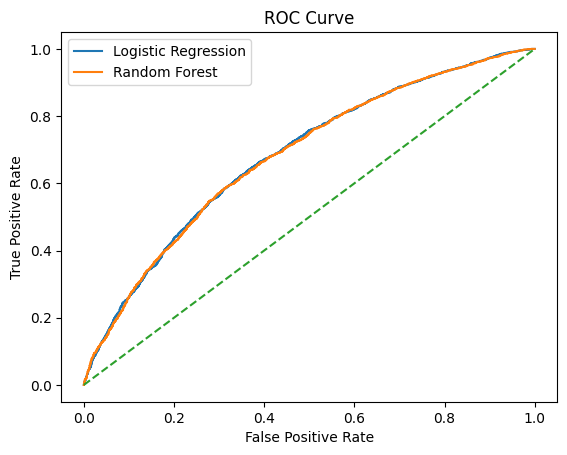

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

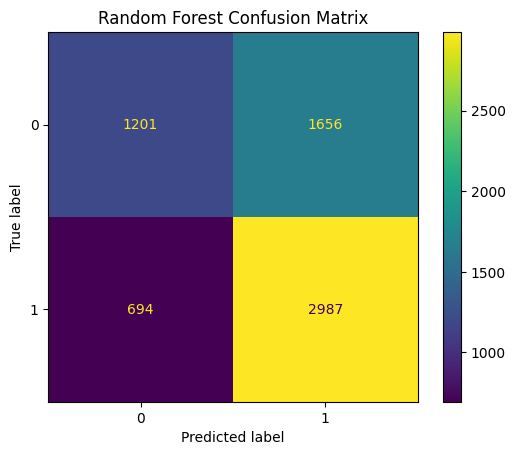

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

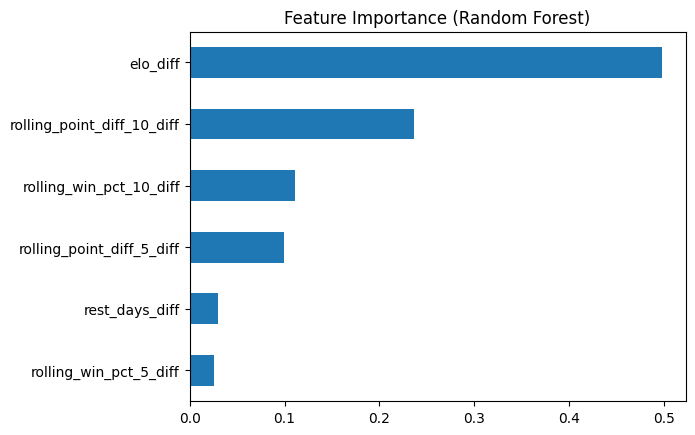

In [49]:
import pandas as pd

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values()

importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()

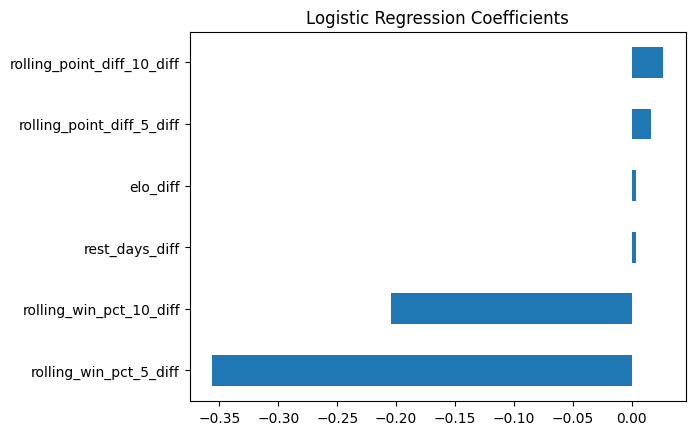

In [50]:
coeffs = pd.Series(
    log_model.coef_[0],
    index=feature_cols
).sort_values()

coeffs.plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.show()

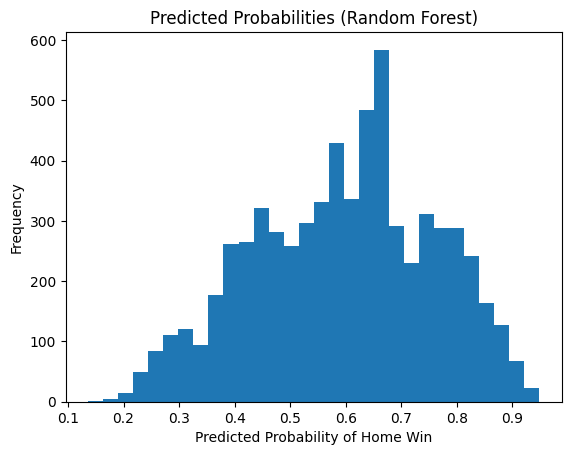

In [51]:
plt.figure()
plt.hist(y_prob_rf, bins=30)
plt.title("Predicted Probabilities (Random Forest)")
plt.xlabel("Predicted Probability of Home Win")
plt.ylabel("Frequency")
plt.show()

In [52]:
baseline_pred = [1] * len(y_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))


Baseline Accuracy: 0.5630162129091465
Logistic Accuracy: 0.6396451514224534
RF Accuracy: 0.640562863260936


In [61]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression(max_iter=1000)

param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_logreg = GridSearchCV(
    logreg,
    param_grid_logreg,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_logreg.fit(X_train, y_train)

print("Best params:", grid_logreg.best_params_)
print("Best CV score:", grid_logreg.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......................C=1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ......................C=1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, s

In [62]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   1.2s
[CV] END max_depth=5, min_samples_leaf

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 3],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 300]},
             scoring='roc_auc', verbose=2)

In [63]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.7s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.0s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   1.7s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   2.3s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   1.1s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   2.4s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   2.7s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   3.1s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.01, max_depth=5, n_estimators=200; total time=   1.2s
[CV] END ..learning_rate=0.01, max_depth=5, n_es

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5], 'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=2)

In [64]:
results = {
    "LogReg": grid_logreg.best_score_,
    "RF": grid_rf.best_score_,
    "GB": grid_gb.best_score_
}

print(results)

{'LogReg': np.float64(0.7078956057851504), 'RF': np.float64(0.7042741724804882), 'GB': np.float64(0.7049420520271291)}


In [74]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6516 - loss: 0.6303 - val_accuracy: 0.6579 - val_loss: 0.6168
Epoch 2/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.6636 - loss: 0.6199 - val_accuracy: 0.6617 - val_loss: 0.6158
Epoch 3/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.6667 - loss: 0.6159 - val_accuracy: 0.6589 - val_loss: 0.6219
Epoch 4/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.6641 - loss: 0.6149 - val_accuracy: 0.6602 - val_loss: 0.6158
Epoch 5/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.6671 - loss: 0.6157 - val_accuracy: 0.6615 - val_loss: 0.6193
Epoch 6/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - accuracy: 0.6658 - loss: 0.6147 - val_accuracy: 0.6609 - val_loss: 0.6150
Epoch 7/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.6659 - loss: 0.6161 - val_accuracy: 0.6597 - val_loss: 0.6153
Epoch 8/50
496/496 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.6648 - loss: 0.6135 - va

In [76]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.6395 - loss: 0.6375
Test accuracy: 0.6394922137260437


In [77]:
learning_rates = [1e-3, 5e-4]
batch_sizes = [32, 64]
hidden_units = [32, 64, 128]

results = []

for lr in learning_rates:
    for bs in batch_sizes:
        for hu in hidden_units:
            
            model = models.Sequential([
                layers.Dense(hu, activation='relu', input_shape=(X_train.shape[1],)),
                layers.Dense(hu//2, activation='relu'),
                layers.Dense(1, activation='sigmoid')
            ])

            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss='binary_crossentropy',
                metrics=['accuracy']
            )

            history = model.fit(
                X_train, y_train,
                validation_split=0.2,
                epochs=20,
                batch_size=bs,
                verbose=0
            )

            val_roc_auc = max(history.history['val_accuracy'])

            results.append((lr, bs, hu, val_roc_auc))

sorted(results, key=lambda x: -x[3])[:5]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object 

[(0.001, 32, 128, 0.664228081703186),
 (0.0005, 32, 32, 0.6639757752418518),
 (0.001, 32, 64, 0.6634712219238281),
 (0.001, 64, 64, 0.6634712219238281),
 (0.001, 64, 128, 0.6632189750671387)]

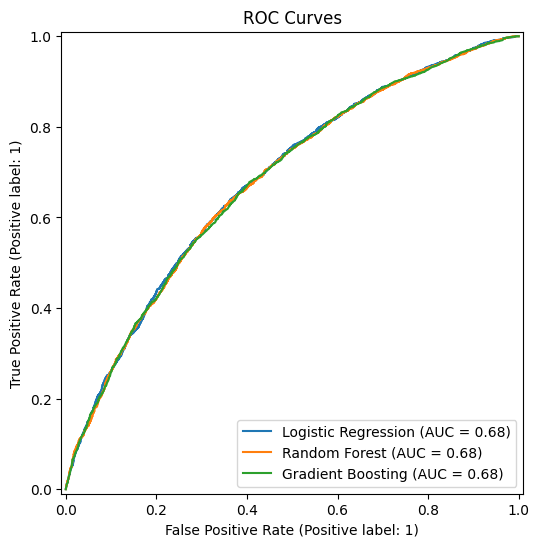

In [65]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_estimator(grid_logreg.best_estimator_,
                               X_test, y_test,
                               ax=ax,
                               name='Logistic Regression')

RocCurveDisplay.from_estimator(grid_rf.best_estimator_,
                               X_test, y_test,
                               ax=ax,
                               name='Random Forest')

RocCurveDisplay.from_estimator(grid_gb.best_estimator_,
                               X_test, y_test,
                               ax=ax,
                               name='Gradient Boosting')

plt.title("ROC Curves")
plt.show()

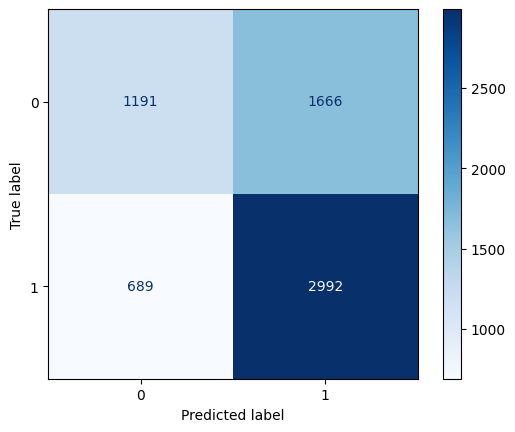

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_logreg.best_estimator_,
    X_test,
    y_test,
    cmap="Blues"
)

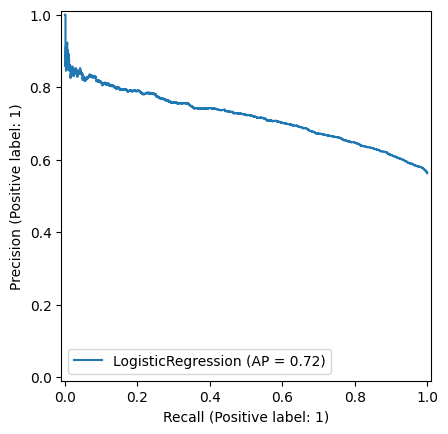

In [67]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    grid_logreg.best_estimator_,
    X_test,
    y_test
)

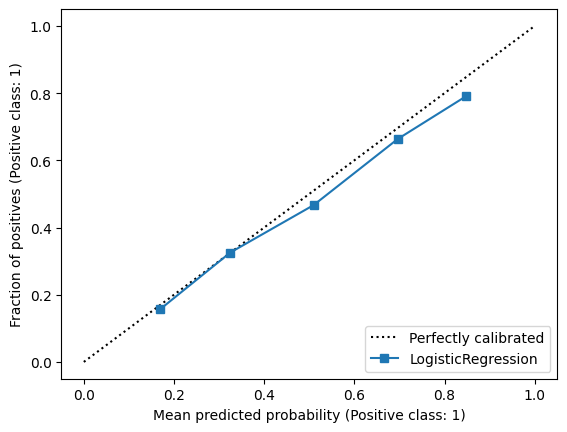

In [69]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    grid_logreg.best_estimator_,
    X_test,
    y_test
)

<Axes: >

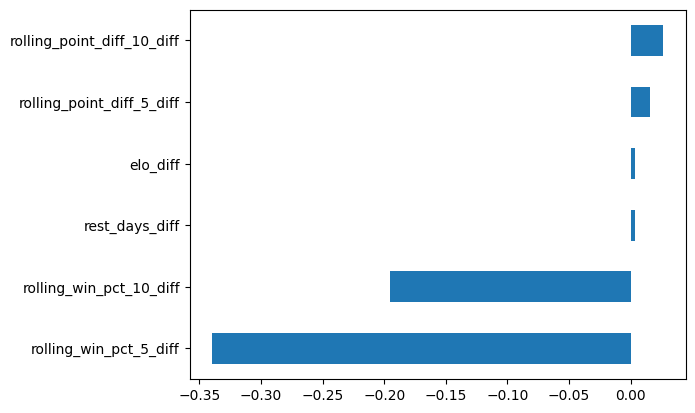

In [70]:
coef = pd.Series(
    grid_logreg.best_estimator_.coef_[0],
    index=X_train.columns
)

coef.sort_values().tail(15).plot.barh()